## Modelos basados en un parámetro

### Modelo Gamma Poisson 


El siguiente modelo que pertenece a los modelos conjugados en donde la distribución prior  gamma es la misma que la distribución posterior mientras que la distribución likelihood es la poisson. 

La distribución poisson tiene  un parámetro $\theta$ que implica el promedio de eventos en un período de tiempo. 

$$ P(Y\mid \theta)=\theta^{y}\frac{e^{-\theta}}{y!} = \prod_{i=1}^{n}\frac{\theta^{y}e^{-\theta}}{y!} =  \frac{\theta^{\sum_{i=1}^{n}y_{i}}e^{-n\theta}}{\prod_{i=1}^{n}y!} \quad para  \quad y \in \{0,1,2,...\}$$


La distribución prior es una distribución gamma  

$$p(\theta)=\frac{b^{a}}{\Gamma(a)}\theta^{a-1}e^{-b\theta}$$


Siendo $a, b $ valores constantes y $y$ observaciones, para  ambas funciones en donde estos no tiene relación con $\theta$ estos valores se pueden tomar de forma constante y  calculando la distribución posterior se obtiene:



\begin{align}
p(\theta \mid y_{1},...,y_{n}) &= (\theta^{a-1}e^{-b\theta}))(\theta^{\sum y_{i}}e^{-n\theta})c(y_{1},...,y_{n},a,b) & \\
&= ( \theta^{a+\sum y_{i}-1} e^{-(b+n)\theta}) c(y_{1},...,y_{n},a,b) &\\
p(\theta \mid y_{1},...,y_{n}) &\propto \theta^{a+\sum y_{i}-1} e^{-(b+n)\theta}
\end{align}


Donde $(\theta \mid y) \sim gamma(a+\sum_{i=1}^{n}Y_{i},b+n)$


El valor esperado de la distribución posterior es

* $E[\theta \mid y_{1},...,y_{n}]=\frac{a+\sum y_{i}}{b+n}$
* $V[\theta \mid y_{1},...,y_{n}]= \overline{y}/n$


* b se interpretra como el número de observaciones a priori.
* a se interpretra como la suma de los conteos  de las observaciones a priori de b.

### Ejemplo

Dadas las condiciones económicas de un país, se cree que la situación financiera de de varios bancos puede estar en peligro. La razón principal es que algunos deudores de estos bancos  se están atrasando en las cuotas de los préstamos hipotecarios. Los clientes de cada banco así como los deudores que están incumpliendo sus cuotas se pueden ver a continuación:



Banco | clientes | Deudores atrasados
:--------: | ------- | :--------:
A | 124 | 4
B | 235 | 5
C | 219 | 3
D | 159 | 6
E | 229 | 4
F | 176 | 7

Se supone que el número $Y_{i}$ de clientes de un banco $n_{i}$ es una variable aleatoria que sigue una distribución poisson con media $n_{i}\theta$. El número en cada banco es independiente de otros bancos dado un valor $\theta$. La distribución prior de $\theta$ sigue una distribución gamma con media de 5 y varianza 2. 

Para obtener los valores de la distribución prior a y b estos se despejan del valor esperado y la varianza de la distribución gamma

$$5=a/b= E[\theta]$$

$$2=a/b^{2} = V[\theta]$$

$$2b^{2}=a $$

$$5=2b$$

$$b=2.5$$

$$2.5^2 2= a$$

$$a=12.5$$




In [20]:
from scipy.stats import poisson
from scipy.stats import gamma
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
## Para obtener los valores de la distribución prior a y b estos se despejan del valor 
## esperado y la varianza.
b=5/2
a=2*b**2
print(a,b)

theta= np.arange(0, 15, 0.1).tolist()
distgprior = [gamma.pdf(r, a, scale=1/b) for r in theta ] ## Leer documentación para b que en python se incluye de forma inversa






12.5 2.5


Text(0.5, 1.0, 'Gamma Prior$ \\quad a= 12.5 , b= 2.5$')

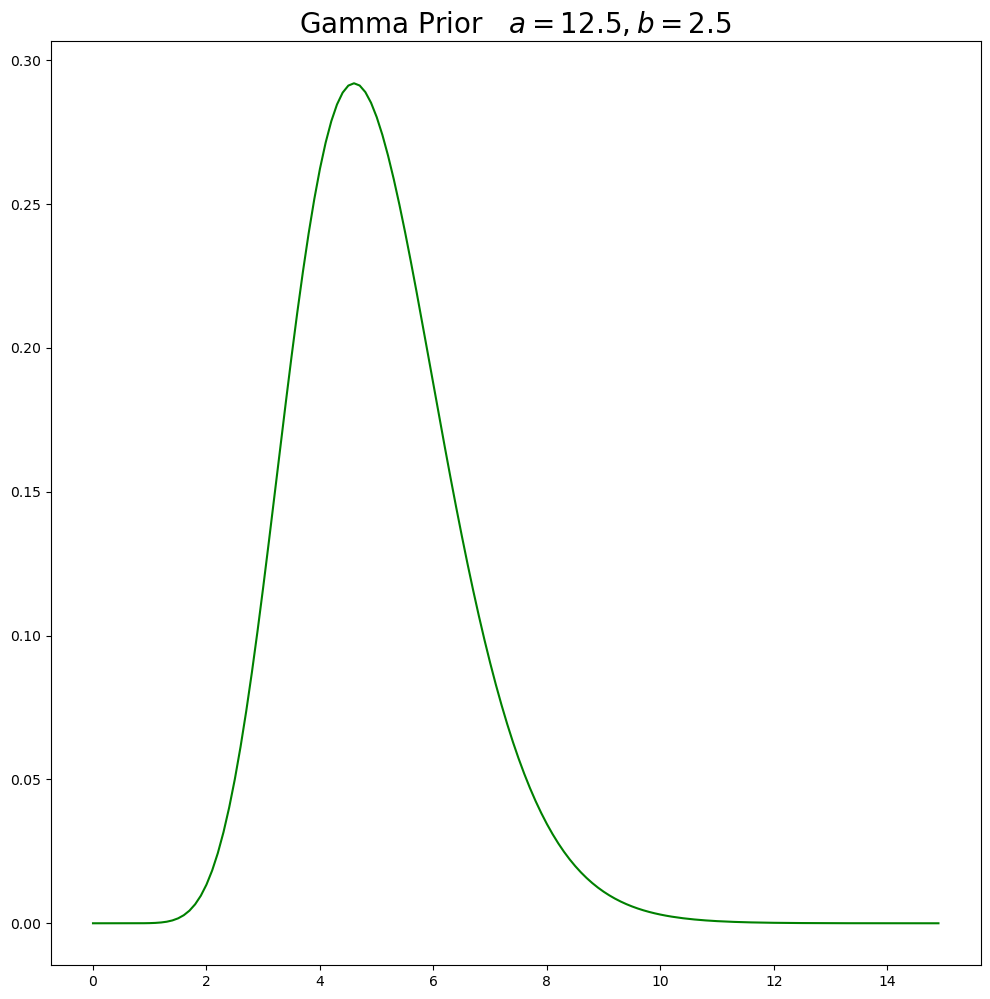

In [21]:
plt.figure(figsize=(12, 12))
plt.plot(theta, distgprior, color="green")
plt.title(  "Gamma Prior"  r'$ \quad a= 12.5 , b= 2.5$',fontsize=20)


En el caso de la distribución  poisson que es la likelihood, se contabiliza el total de clientes en todos los bancos, así como los que están entrando en cesión de pagos hipotecarios.



$$ P(Y\mid \theta)=\theta^{y}\frac{e^{-\theta}}{y!} = \prod_{i=1}^{n}\frac{\theta^{y}e^{-\theta}}{y!} =  \frac{\theta^{29}e^{-1142\theta}}{\prod_{i=1}^{6}y!} $$

Que es proporcional a:


$$P(Y\mid \theta) = \theta^{29}e^{-1142\theta}$$


Dejando de lado los valores de los que no depende $\theta$

In [15]:
clientes=np.array( [124, 235 ,219, 159, 229 ,176],dtype=int)
defcli=np.array([4, 5,  3, 6, 4,7], dtype=int)
sumclien=np.sum(clientes)
sumdef=np.sum(defcli)
theta= np.arange(0, 1, 0.1).tolist()
distplik = [poisson.pmf(sumdef,sumclien*r ) for r in theta ]


Text(0.5, 1.0, 'Likelihood Poisson$ \\quad \\sum y_{i}= 29 , \\sum n_{i} = 1142$')

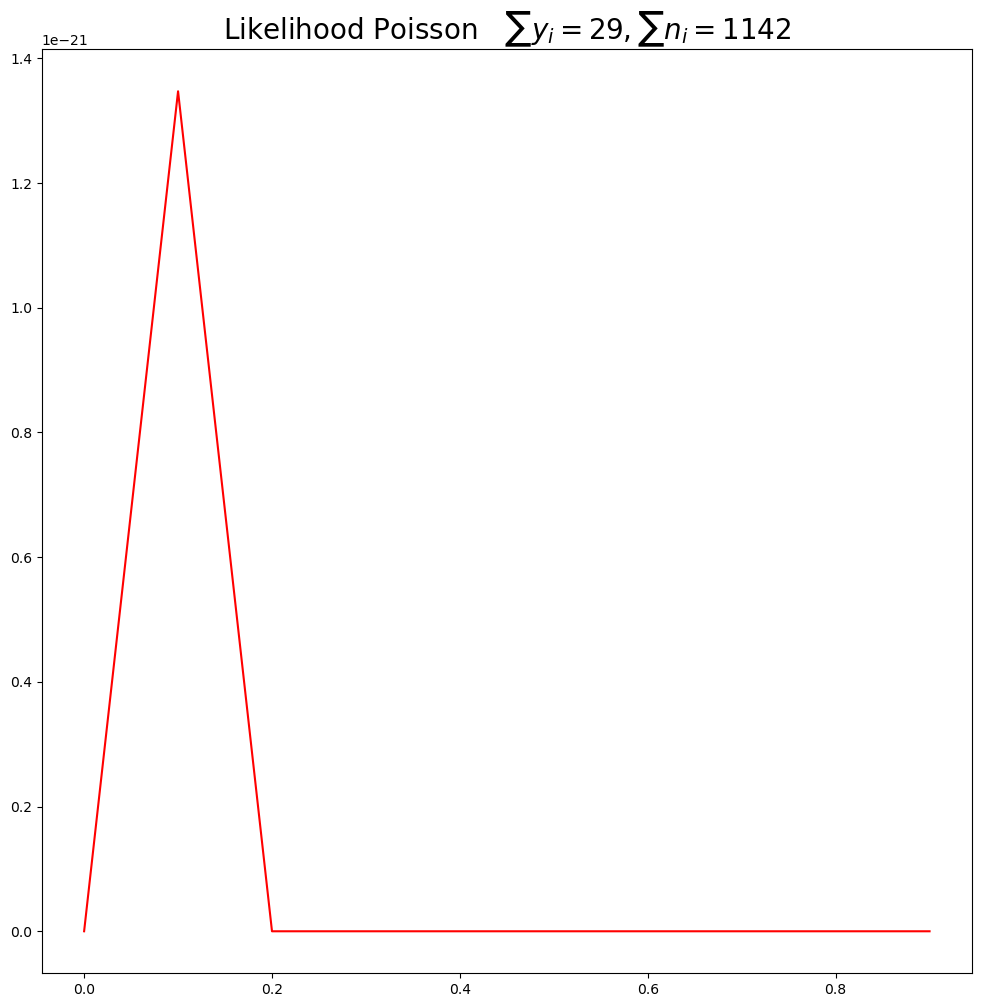

In [16]:
plt.figure(figsize=(12, 12))
plt.plot(theta, distplik, color="red")
plt.title(  "Likelihood Poisson"  r'$ \quad \sum y_{i}= 29 , \sum n_{i} = 1142$',fontsize=20)


Finalmente se obtiene la distribución posterior que como se mencionó anteriormente vuelve a ser una distribución gamma dando su propiedad de distribución conjugada.

$$p(\theta \mid y_{1},...,y_{1142}) \propto \theta^{12.5+29} e^{-(2.5+1142)\theta}$$

Donde $(\theta \mid y) \sim gamma(12.5+29,2.5+1142)$


Text(0.5, 1.0, 'Gamma Posterior$ \\quad a= 12.5+29 , b= 2.5+1142 $')

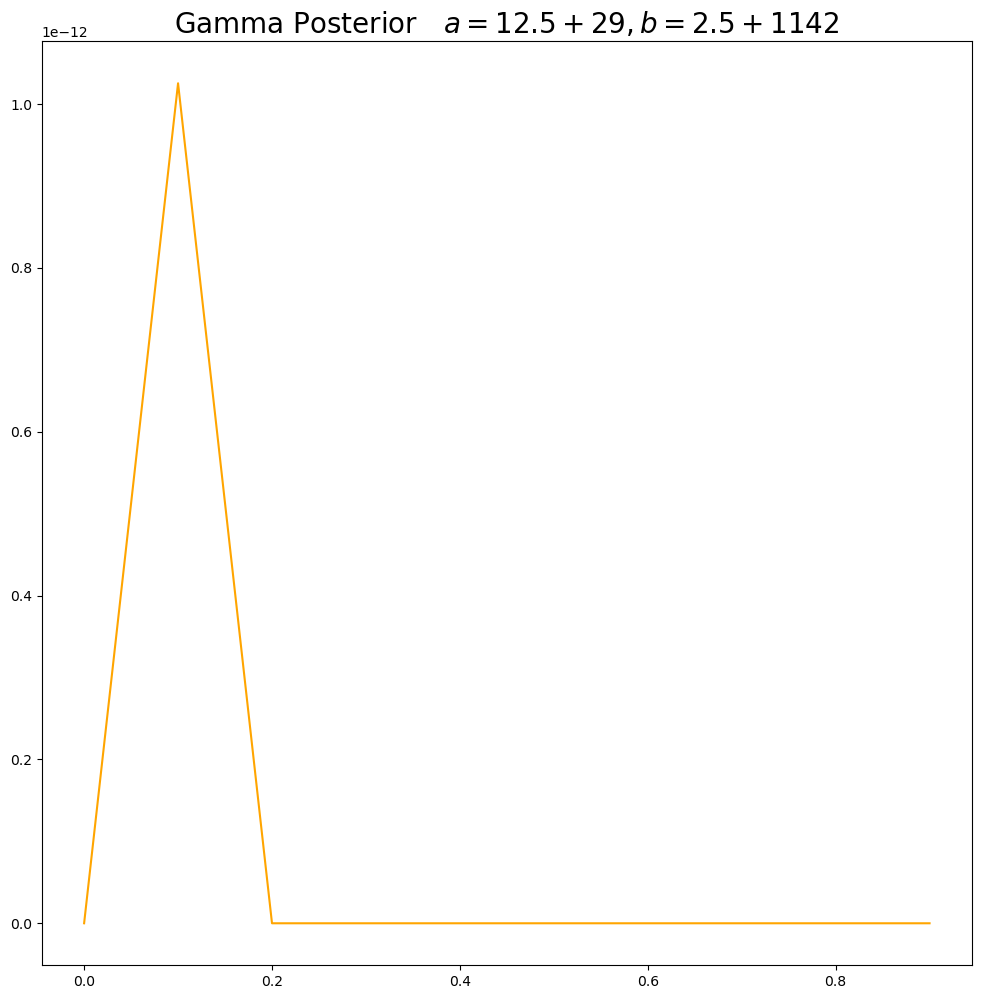

In [17]:
theta= np.arange(0, 1, 0.1).tolist()
distgprior = [gamma.pdf(r, a+sumdef, scale=1/(b+sumclien)) for r in theta ] ## Leer documentación para b que en python se incluye de forma inversa
plt.figure(figsize=(12, 12))
plt.plot(theta, distgprior, color="orange")
plt.title(  "Gamma Posterior"  r'$ \quad a= 12.5+29 , b= 2.5+1142 $',fontsize=20)

El valor esperado y la varianza de la distribución posterior es igual a:


* $E[\theta \mid y_{1},...,y_{1142}]=\frac{12.5+29}{2.5+1142}$
* $V[\theta \mid y_{1},...,y_{1142}]= 0.0024/1142$


In [44]:
EPost=(a+sumdef)/(b+sumclien)
VPost=(sumdef/sumclien)/sumclien
data = {'Valor Esperado Posterior': [EPost], 'Varianza Posterior': [VPost]}    
# Create DataFrame  
df = pd.DataFrame(data)  
df  

,Valor Esperado Posterior,Varianza Posterior
0,0.03626,0.000022


De acuerdo al resultado anterior, se puede decir que se espera que menos de un cliente en promedio entre en cesión de pagos, sugieriendo que a pesar de la crisis económica  los bancos no necesariamente  pueden tener dificultades debido al incremento de clientes que se pueden atrasar en el pago de sus cuotas hipotecarias, dado que son muy pocos los que entrarian en cesión de pagos.

La predicción de este modelo tiene una característica especial puesto que el resultado que arroja es equivalente al que se tiene en una distribución binomial negativa.

Usando la formula para obtener la predicción de una posterior se tiene que :

\begin{align}
p(\tilde{y} \mid y) &=\int p(\tilde{y},\theta \mid y) d\theta & \\
&=  \int poisson(\tilde{y}, \theta) gamma(a+\sum y_{i}, b+n) d\theta & \\
&=  \int \Big(\frac{1}{\tilde{y}!}\theta^{\tilde{y}}e^{-\theta}\Big)\Big(\frac{(b+n)^{a+\sum y_{i}}}{\Gamma(a+\sum y_{i})}\theta^{a+\sum y_{i}-1}e^{-(b+n)\theta}\Big)
\end{align}


Resolviendo esta integral e igualando a uno, el resultado que se obtiene es:


$$p(\tilde{y}\mid y_{1},...,y_{n})=\frac{\Gamma(a+\sum y_{i}+\tilde{y})}{\Gamma(\tilde{y}+1)\Gamma(a+\sum y_{i})}\Big(\frac{b+n}{b+n+1}\Big)^{a+\sum y_{i}}\Big(\frac{1}{b+n+1}\Big)^{\tilde{y}}$$


Esta es una distribución binomial negativa con parámtros $(a+\sum y_{i},b+n)$. 

* El valor esperado es $E[\tilde{Y}\mid y_{1},...,y_{n}]=\frac{a+\sum y_{i}}{b+n}$
* La varianza es $V[\tilde{Y}\mid y_{1},...,y_{n}]=\frac{a+\sum y_{i}}{b+n}\frac{b+n+1}{b+n}$


Text(0.5, 1.0, 'Prediction Posterior Negativa Binomial$ \\quad n= 12.5+29 , p= (12.5+29)/ (2.5+1142) $')

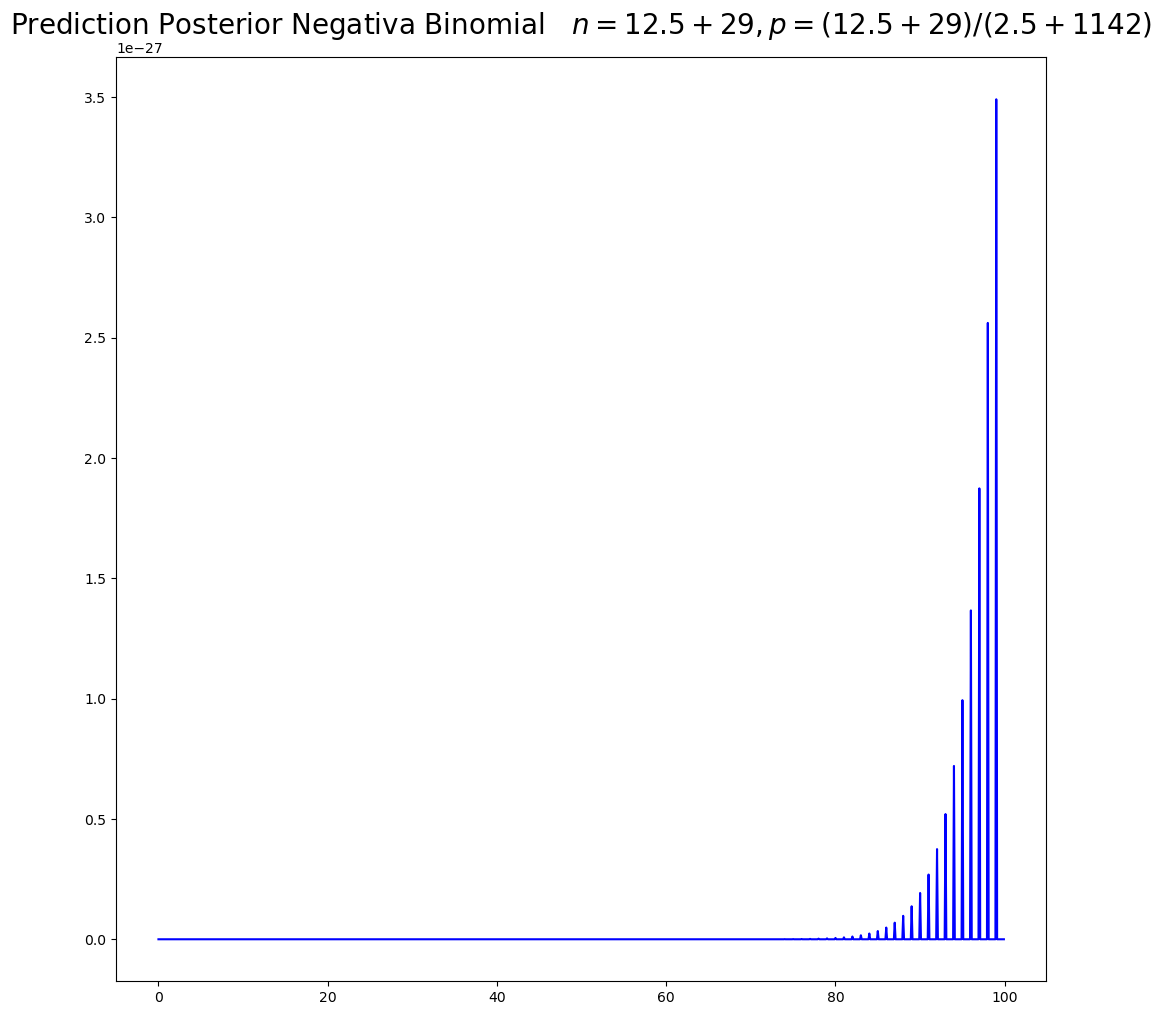

In [19]:
### La predicción para el ejemplo anterior se puede ver como un resultado de la distribución
### negativa binomial
from scipy.stats import nbinom
ypred= np.arange(0, 100, 0.1).tolist()
preddistnbinom = [nbinom.pmf(r,np.round(a+sumdef),(a+sumdef)/(b+sumclien) ) for r in ypred ]
plt.figure(figsize=(12, 12))
plt.plot(ypred, preddistnbinom, color="blue")
plt.title(  "Prediction Posterior Negativa Binomial"  r'$ \quad n= 12.5+29 , p= (12.5+29)/ (2.5+1142) $',fontsize=20)

Aproximadamente de 90 clientes uno se atrasará en las cuotas hipotecarias de acuerdo a la gráfica que se puede ver de la distribución binomial negativa.

### Alternativas para la construcción de los parámetros a priori 

Una de las grandes dificultades de la estadística bayesiana se encuentra en la forma como se asume información a partir de procesos subjetivos que se ven reflejados en la construcción de las distribuciones a priori. Cuando las distribuciones previas no tienen una base poblacional, pueden ser difíciles de construir, pero además una de las grandes críticas a la construcción de esta distribuciones es la falta de rigurosidad en la elección de los parámetros. Estas distribuciones a veces se denominan "distribuciones previas de referencia" y la densidad previa se describe como vaga, plana, difusa o no informativa. A menudo se dice que la razón para usar distribuciones previas no informativas es "dejar que los datos hablen por sí mismos", de modo que las inferencias no se vean afectadas por información externa a los datos actuales. No obstante, esto puede entrar enb contravia con lo que se busca algunas veces al tener en cuenta la opinión de los expertos reflejada en esa información inicial.


Para mejorar el cálculo de los parámetros previos o prior, Jeffreys(1961) sugiere una regla que permita obtener esta información a directamente del resultado de la matriz  de Fisher. 

El proceso se realiza con ayuda de la trasnformación del parámetro que se desea calcular $\phi=h(\theta)$ este proceso tiene una ventaja y es que es invariante por lo que la trasformación es proporcional al proceso implementado en la regla bayesiana.


La densidad se calcula a partir de:


$$p(\phi)=p(\theta) \begin{vmatrix}
 \frac{d\theta}{d\phi}
\end{vmatrix} = p(\theta)\vert h´(\theta) \vert^{-1} $$


El modelo trasnformado es igual a $p(y,\phi)=p(\phi)p(y\mid \phi)$ 


El resultado se puede leer como una densidad no informativa  $p(\theta) \propto [J(\theta)]^{1/2}$ donde $J(\theta)$ es la información de Fisher para $\theta$.


$$ J(\theta)=E\Big(\Big(\frac{dlog p(y\mid \theta)}{d\theta}\Big)^{2}\Big) \mid \theta \Big)=-E\Big(\frac{d^{2}logp(y\mid \theta) }{d\theta^{2}}\mid \theta\Big)$$



Aplicando este proceso a la distribución binomial, se tiene que los parámetros de la distribución prior son  $beta(\theta,1/2,1/2)$.

$$f(y \mid n, \theta)= \binom{n}{y} \theta^{y}(1-\theta)^{n-y}$$

$$logf(y \mid \theta)=\log \binom{n}{y} +y \log \theta+(n−y)\log(1−\theta)$$ 

$$\frac{d\log}{d\theta}\log f(y\mid \theta)=\frac{y}{\theta}-(n-x) \frac{1}{1-\theta}$$

$$\frac{d\log}{d\theta^{2}}\log f(y\mid \theta)=-\frac{y}{\theta^{2}}-\frac{n-y}{(1-\theta)^{2}}$$

Para $E[y]=n\theta$

$$I(\theta)=-E[y\mid \theta]\Big[\frac{d^{2}}{d\theta^{2}}logf(y\mid \theta)\Big]=-E\Big(-\frac{y}{\theta^{2}}-\frac{n-y}{(1-\theta^{2})}\Big)=\frac{n}{\theta(1-\theta)} $$

$$[I(\theta)]^{1/2}=n^{1/2}\theta^{-1/2}(1-\theta)^{-1/2}$$

$$p(\theta)\propto [I(\theta)]^{1/2}\propto \theta^{-1/2}(1-\theta)^{-1/2}$$


Aplicando la Jeffrey prior para el modelo poisson, se obtienen los parámetros a priori de una distribución gamma 

\begin{align}
\ell(y \mid \theta) &= \log p(y \mid \theta) \\
&= \log \left( \frac{\theta^y e^{-\theta}}{y!} \right) \\
&= \log \left( \frac{1}{y!} \right) + y \log (\theta) - \theta \\
\ell_\theta(y \mid \theta) &= \frac{y}{\theta} - 1\\
\ell_{\theta \theta}(y \mid \theta) &= -\frac{y}{\theta^2} \\
\end{align}




Haciendo unos cálculos la Jeffreys prior es:

\begin{align}
p_J(\theta) &= c \times \sqrt{\frac{1}{\theta}} \\
&= c \times \frac{1}{\sqrt{\theta}}
\end{align}


\begin{align}
f(\theta, y) &= \sqrt{I(\theta)} \times p(y \mid \theta) \\
&= \frac{1}{\sqrt{\theta}} \times  \frac{\theta^y e^{-\theta}}{y!} \\
&= \theta^{-1/2} \times  \frac{\theta^y e^{-\theta}}{\Gamma(y + 1)} \\
&= \theta^{y - 1/2} e^{-\theta} \frac{1}{\Gamma(y + 1)} \\
\end{align}


\begin{align}
 &\propto \theta^{y - 1/2} e^{-\theta} \\
&\propto \text{gamma}(\theta, y + \frac{1}{2},1)
\end{align}